In [ ]:
# Importing the important libraries
import pandas as pd #work with tables (CSV, Excel, DataFrames)
import numpy as np # for the numerical calculations
import matplotlib.pyplot as plt # for the plots
import seaborn as sns # for better looking charts

pd.options.display.float_format = '{:,.2f}'.format #Formatted numeric display( instead of the scientic format which is hard to read)

In [ ]:
# loading the data
from google.colab import files
files.upload()
df = pd.read_excel("bitcoin_trade_2010-25.xlsx")
df.head()


Saving bitcoin_trade_2010-25.xlsx to bitcoin_trade_2010-25.xlsx


,Time,bitfinex,bitstamp,btcchina,coinbase,huobi,kraken,lakebtc,mtgox,okcoin,others
0,2010-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"31,858.88",NaN,NaN
1,2010-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"221,738.77",NaN,NaN
2,2010-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"216,812.06",NaN,NaN
3,2010-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,105,927.96",NaN,NaN
4,2010-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"826,247.00",NaN,NaN


In [ ]:
df.tail()

,Time,bitfinex,bitstamp,btcchina,coinbase,huobi,kraken,lakebtc,mtgox,okcoin,others
180,2025-07-01,"10,981.53","45,882.41",NaN,"235,390.08",NaN,"17,309.95",NaN,NaN,NaN,"3,381.23"
181,2025-08-01,"15,625.06","46,375.37",NaN,"135,971.14",NaN,"17,355.88",NaN,NaN,NaN,"3,437.17"
182,2025-09-01,"13,360.20","51,078.76",NaN,NaN,NaN,"14,590.76",NaN,NaN,NaN,"3,161.55"
183,2025-10-01,"31,185.16","76,906.58",NaN,NaN,NaN,"28,883.12",NaN,NaN,NaN,"5,163.57"
184,2025-11-01,"42,812.58","94,549.12",NaN,NaN,NaN,"36,405.55",NaN,NaN,NaN,"5,407.48"


In [ ]:
#Understanding the data
df.columns

Index(['Time', 'bitfinex', 'bitstamp', 'btcchina', 'coinbase', 'huobi',
       'kraken', 'lakebtc', 'mtgox', 'okcoin', 'others'],
      dtype='object')

These columns shows the Bitcoin trading volume on these exchanges/sites.

*  Date col represent the  Date / time of trading data.
*  Each column (except Time) is a website where people buy and sell Bitcoin.

* **USD-based exchanges**
→ Coinbase, Kraken, Bitstamp

*  **China (non-USD) exchanges**
→ Huobi, OKCoin, BTCChina

*  **International / Mixed exchanges**
→ Bitfinex, LakeBTC, Mt. Gox, Others

International / mixed:People from many different countries use this site, and no single country or currency clearly dominates.













In [ ]:
df.dtypes


,0
Time,datetime64[ns]
bitfinex,float64
bitstamp,float64
btcchina,float64
coinbase,float64
huobi,float64
kraken,float64
lakebtc,float64
mtgox,float64
okcoin,float64


In [ ]:
df.shape
#The dataset contains time-series Bitcoin trading volume across multiple exchanges

(185, 11)

In [ ]:
df["Time"].head(10)

,Time
0,2010-07-01
1,2010-08-01
2,2010-09-01
3,2010-10-01
4,2010-11-01
5,2010-12-01
6,2011-01-01
7,2011-02-01
8,2011-03-01
9,2011-04-01


In [ ]:
df["Time"].diff().value_counts().head()

,count
Time,
31 days,108
30 days,61
28 days,11
29 days,4



This shows that

*   31 days → 108 times
*   30 days → 61 times
*   28 days → 11 times
*   29 days → 4 times


*   Some months have 31 days
*   Some have 30 days
*   February has 28 or 29 days


*   Each row represents one month of Bitcoin trading activity.
*   The Bitcoin data is monthly time-series data from 2010 to 2025.






In [ ]:
#converting time col to date
df["Time"]=pd.to_datetime(df["Time"])
#This is only when the time is not in datetime64[ns]. but in our dataset its already in the correct format.

In [ ]:
df["Time"].dtype # means the time col is convered to date

dtype('<M8[ns]')

In [ ]:
df["Time"].head()

,Time
0,2010-07-01
1,2010-08-01
2,2010-09-01
3,2010-10-01
4,2010-11-01


In [ ]:
df['year']=df['Time'].dt.year
df['month'] = df['Time'].dt.to_period('M')

In [ ]:
df.head()


,Time,bitfinex,bitstamp,btcchina,coinbase,huobi,kraken,lakebtc,mtgox,okcoin,others,year,month
0,2010-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"31,858.88",NaN,NaN,2010,2010-07
1,2010-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"221,738.77",NaN,NaN,2010,2010-08
2,2010-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"216,812.06",NaN,NaN,2010,2010-09
3,2010-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,105,927.96",NaN,NaN,2010,2010-10
4,2010-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"826,247.00",NaN,NaN,2010,2010-11


In [ ]:
# checking the missing values
df.isna().sum()

,0
Time,0
bitfinex,32
bitstamp,14
btcchina,109
coinbase,56
huobi,140
kraken,38
lakebtc,149
mtgox,141
okcoin,137


Since we have missing values, need to fill these with 0.

In [ ]:
df.fillna(0,inplace=True) # replacing the (null/NaN) values with 0

In [ ]:
df.isna().sum()

,0
Time,0
bitfinex,0
bitstamp,0
btcchina,0
coinbase,0
huobi,0
kraken,0
lakebtc,0
mtgox,0
okcoin,0


Now we dont have any missing values


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
180,False
181,False
182,False
183,False


Now we dont have any duplicate values

In [ ]:
# Dropping the duplicates if any
df=df.drop_duplicates()

In [ ]:
exchange_cols = [
    "bitfinex", "bitstamp", "btcchina", "coinbase",
    "huobi", "kraken", "lakebtc", "mtgox", "okcoin", "others"]
df[exchange_cols] = df[exchange_cols].apply(pd.to_numeric, errors="coerce") # Converting exchange columns to numeric
df[exchange_cols] = df[exchange_cols].fillna(0) # Filling missing values


In [ ]:
df[exchange_cols].dtypes
#Since our data has decimals → float64.

,0
bitfinex,float64
bitstamp,float64
btcchina,float64
coinbase,float64
huobi,float64
kraken,float64
lakebtc,float64
mtgox,float64
okcoin,float64
others,float64


Creating a new col(exchange_cols) which cantains the exchange data for all countries. This is converted into numberic cols.

**---Basic statistical summary---**

Bitcoin trading data aggregated into USD-based, China-based, and international categories to enable comparative statistical analysis.

In [ ]:
#creating the grouped cols
df["usd_exchanges"] = df["bitstamp"]+df["kraken"]+df["coinbase"]
df["china_exchanges"] = df["huobi"] + df["okcoin"] + df["btcchina"]
df["other_exchanges"] = (
    df["bitfinex"] +
    df["lakebtc"] +
    df["mtgox"] +
    df["others"]
)



*   USD_Exchanges: Total Bitcoin trading happening via USD-based platforms
*   China_Exchanges; Total Bitcoin trading via China-based platforms
*   Other_Exchanges: Bitcoin trading via globally mixed platforms






In [ ]:
#Creating the a col for all the excahnges
df["Total_Exchanges"] = (
    df["usd_exchanges"] +
    df["china_exchanges"] +
    df["other_exchanges"]
)

In [ ]:
df[[
    "usd_exchanges",
    "china_exchanges",
    "other_exchanges",
    "Total_Exchanges"
]].head(80)


,usd_exchanges,china_exchanges,other_exchanges,Total_Exchanges
0,0.00,0.00,"31,858.88","31,858.88"
1,0.00,0.00,"221,738.77","221,738.77"
2,0.00,0.00,"216,812.06","216,812.06"
3,0.00,0.00,"1,105,927.96","1,105,927.96"
4,0.00,0.00,"826,247.00","826,247.00"
...,...,...,...,...
75,"410,143.67","112,660,384.25","2,692,738.06","115,763,265.98"
76,"527,532.25","172,148,942.46","2,974,546.67","175,651,021.38"
77,"618,833.37","167,457,422.23","3,080,249.35","171,156,504.96"
78,"1,018,955.14","103,809,546.82","3,379,421.57","108,207,923.54"


In [ ]:
#overall stats
df[[
    "usd_exchanges",
    "china_exchanges",
    "other_exchanges"
]].describe()



,usd_exchanges,china_exchanges,other_exchanges
count,185.00,185.00,185.00
mean,"718,280.11","7,510,411.53","1,420,337.58"
std,"567,153.41","25,791,364.89","1,388,679.60"
min,0.00,0.00,"1,844.96"
25%,"323,644.09",0.00,"208,586.68"
50%,"627,521.82",0.00,"1,014,827.62"
75%,"965,694.55","785,549.04","2,354,192.66"
max,"2,558,136.44","172,148,942.46","7,204,516.44"



*   185 time observations(months)
*   mean (AVERAGE Vlaues): China-based exchanges have a much higher average volume(On average, ~7.5 million BTC per month were traded on China-based exchanges)
*  std: China exchanges are extremely volatile. Bitcoin trading in China goes from very low to very high very suddenly. It is not steady or regular.
China-based exchanges exhibit significantly higher volatility, suggesting that Bitcoin usage in non-USD regions intensifies during periods of market stress or regulatory change.USD exchanges are more stable.
* 25% (first quartile): it means For 25% of the time, China exchanges had zero activity. USD: This means that even in low-activity periods, USD exchanges still have substantial Bitcoin trading. This shows continuity and stability.
* 50% (median = typical value): Meaning China trading is event-driven, not continuous. Meaning China trading is event-driven, not continuous.(In more than half the months, China had zero recorded trading volume.)
* 75% (third quartile): 75% of the time, the Bitcoin trading volume was below this value and only 25% of the time, it was above this value. 75% of the time, the Bitcoin trading volume was below this value and only 25% of the time, it was above this value(~966k BTC).China has huge jumps between 75% and max.This shows USD has Mature market behavior & well distributed trading.

    **Is USD dominance weakening?**
*   The third quartile shows that USD trading is stable & USD trading is present in most periods.
*   Although China-based exchanges experience larger episodic spikes, USD-based exchanges continue to handle high trading volumes on a consistent basis.
   












In [ ]:
#total exchange stats
df["Total_Exchanges"].describe()

,Total_Exchanges
count,185.00
mean,"9,649,029.22"
std,"26,349,495.57"
min,"3,210.58"
25%,"869,264.65"
50%,"1,816,002.69"
75%,"4,858,423.09"
max,"175,651,021.38"


In [ ]:
#what percentage of the TOTAL Bitcoin trading volume comes from each group (USD, China, Others)
df["usd_share"] = (df["usd_exchanges"] / df["Total_Exchanges"]) * 100
df["china_share"] = (df["china_exchanges"] / df["Total_Exchanges"]) * 100
df["other_share"] = (df["other_exchanges"] / df["Total_Exchanges"]) * 100


In [ ]:
df[["usd_share", "china_share", "other_share"]].describe()


,usd_share,china_share,other_share
count,185.00,185.00,185.00
mean,39.35,18.24,42.41
std,35.19,32.06,32.00
min,0.00,0.00,1.69
25%,4.79,0.00,12.76
50%,30.00,0.00,30.69
75%,74.77,18.51,68.04
max,95.41,98.01,100.00




*  Out of 100% total Bitcoin trading, how much comes from USD, China, and Others?
*  mean (average share): on an avg, USD handles- 39per, china handles- 185 & ohers is 42.

*   std (volatility of share): All groups show high variability
*   min (lowest observed share): There were periods when:USD & China had no shares.

*   For 25% of the time the share of the Usd was below 4.79% & 50% of the time it was below 30.
*   ***USD dominates often, China spikes occasionally, and international exchanges form the steady core.***
*   *USD-centric platforms remain important.*










**USD dominance change overtime(Year-wise)**

In [ ]:
year_change = df.groupby("year")[[
    "usd_exchanges",
    "china_exchanges",
    "other_exchanges"]].sum()

year_change.head(20)


,usd_exchanges,china_exchanges,other_exchanges
year,,,
2010,0.00,0.00,"2,666,237.77"
2011,"7,553.21","29,310.83","6,224,307.88"
2012,"567,948.56","236,683.70","23,360,250.66"
2013,"4,954,218.85","8,906,045.10","29,767,960.85"
2014,"5,414,298.36","58,487,655.59","18,727,767.27"
2015,"10,176,405.35","210,632,203.52","33,621,240.05"
2016,"7,317,866.22","999,862,807.16","38,476,356.50"
2017,"17,828,285.36","111,271,426.66","41,591,807.31"
2018,"15,664,558.90",0.00,"35,088,102.81"


**Is USD dominance in BTC trading increasing or decreasing?**

In [ ]:
pivot_year = df.groupby("year")[[
    "usd_exchanges",
    "china_exchanges",
    "other_exchanges"
]].sum()

pivot_year_share = pivot_year.div(pivot_year.sum(axis=1), axis=0) * 100
pivot_year_share


,usd_exchanges,china_exchanges,other_exchanges
year,,,
2010,0.00,0.00,100.00
2011,0.12,0.47,99.41
2012,2.35,0.98,96.67
2013,11.36,20.41,68.23
2014,6.55,70.78,22.66
2015,4.00,82.79,13.21
2016,0.70,95.62,3.68
2017,10.44,65.19,24.37
2018,30.86,0.00,69.14


Bitcoin trading has NOT moved away from the USD in the long run.Even tho china was dominating from 2013-2017, but after that USD trading was increasing, showing a strong re-concentration of BTC liquidity in USD markets post-2018.


*   Possible reasons for the china dominace:
*   China has limits on how much money people can move outside the country,Bitcoin may have been used as an alternative way to move or store value.
*   Around that time, there were concerns about the Chinese currency losing value.People might have seen Bitcoin as a way to protect their money
*   Chinese Bitcoin exchanges had very low or zero trading fees,This may have encouraged more trading.
*   Before 2017, crypto regulations in China were not very strict








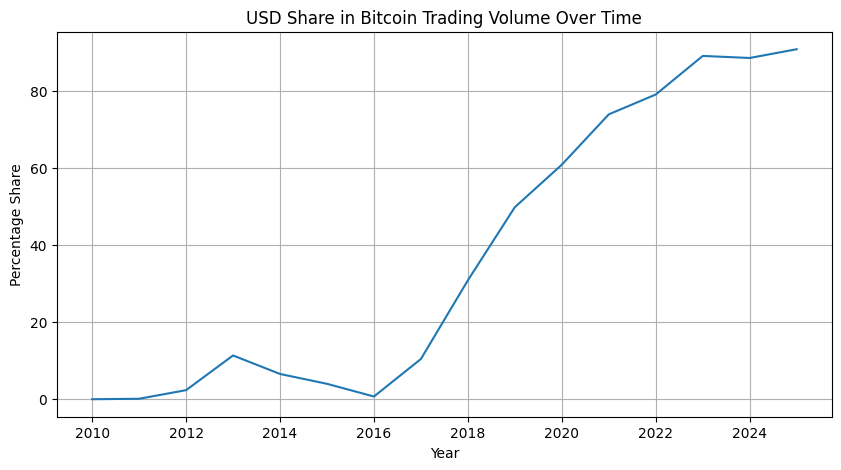

In [ ]:
#USD Trading share over time
pivot_year_share["usd_exchanges"].plot(figsize=(10,5))
plt.title("USD Share in Bitcoin Trading Volume Over Time")
plt.ylabel("Percentage Share")
plt.xlabel("Year")
plt.grid(True)
plt.show()


USD dominance in Bitcoin trading has increased significantly over time, especially after 2017.

*   Possible reasons for the decline:
*   in the early days bitcoin was new & risky. It was mostly used by the Tech communities,these users were not concentrated in the US.
*   US had unclear laws.

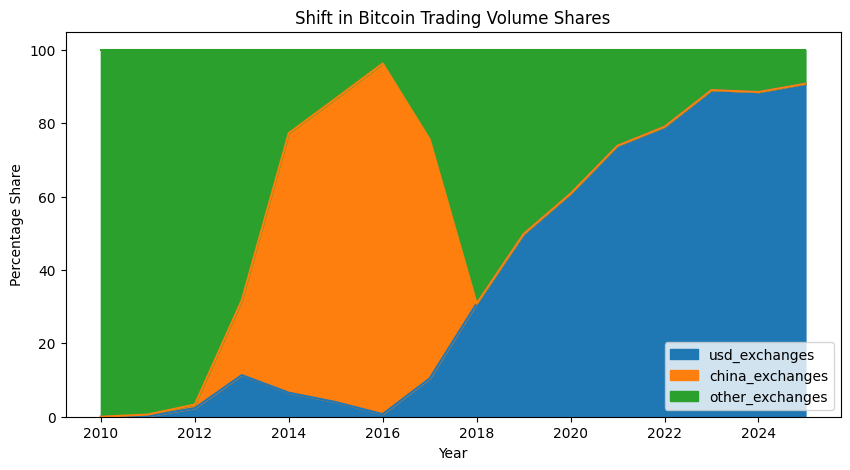

In [ ]:
#Which fiat markets are gaining / losing BTC relevance?
pivot_year_share.plot(kind="area", stacked=True, figsize=(10,5))
plt.title("Shift in Bitcoin Trading Volume Shares")
plt.ylabel("Percentage Share")
plt.xlabel("Year")
plt.show()




*  Bigger colored area = more importance
*  Growing area = gaining relevance
*  Shrinking area = losing relevance


*   Early years (2010–2012): “Other exchanges” dominate
*   2013–2016: China becomes dominant; due to maybe Fewer early regulations.
*   After 2017: China collapses, USD rises strongly. While other exchanges remain active, their relative share has declined as USD markets absorbed most of the global trading volume.








**6. Which fiat currencies are gaining or losing relevance as gateways into
Bitcoin over the last 30 days / 6 months / year?::**

In [ ]:
# Which fiat currencies are gaining or losing relevance as gateways into Bitcoin over the last 30 days / 6 months / year?
latest_date = df['Time'].max()

df_30d = df[df['Time'] >= latest_date - pd.Timedelta(days=30)]
df_6m  = df[df['Time'] >= latest_date - pd.Timedelta(days=180)]
df_1y  = df[df['Time'] >= latest_date - pd.Timedelta(days=365)]


In [ ]:
def group_share(data):
    return data[["usd_exchanges","china_exchanges","other_exchanges"]].sum() / data["Total_Exchanges"].sum() * 100

comparison = pd.DataFrame({
    "30 Days": group_share(df_30d),
    "6 Months": group_share(df_6m),
    "1 Year": group_share(df_1y)
})
comparison.style.format("{:.2f}%")

,30 Days,6 Months,1 Year
usd_exchanges,73.09%,86.97%,91.50%
china_exchanges,0.00%,0.00%,0.00%
other_exchanges,26.91%,13.03%,8.50%


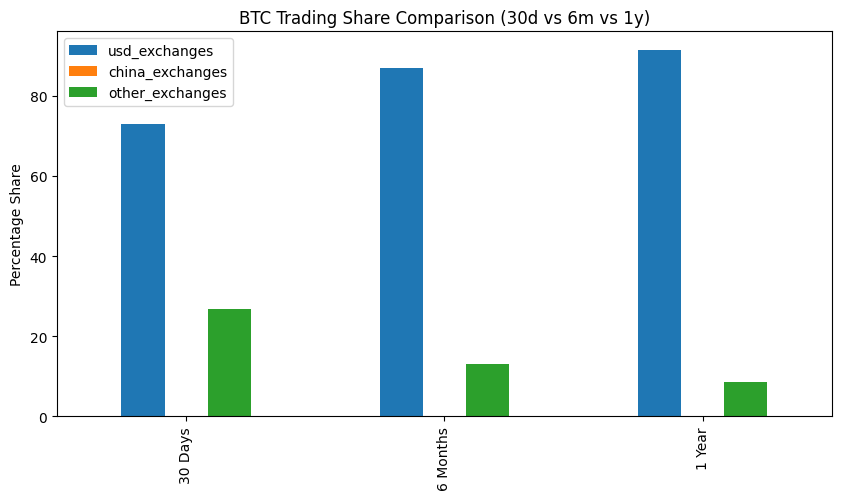

In [ ]:
comparison.T.plot(kind="bar", figsize=(10,5))
plt.title("BTC Trading Share Comparison (30d vs 6m vs 1y)")
plt.ylabel("Percentage Share")
plt.show()




*   China has no Bitcoin trading activity in recent periods
*   The table shows that USD dominates Bitcoin trading in the long term, but in the short term, trading activity is becoming more diversified, with greater participation from non-USD markets





In [ ]:
#What does the BTC Trading trend look like over time?
#Total BTC Trading by year
total_trend = df.groupby("year")["Total_Exchanges"].sum()
total_trend


,Total_Exchanges
year,
2010,"2,666,237.77"
2011,"6,261,171.92"
2012,"24,164,882.91"
2013,"43,628,224.80"
2014,"82,629,721.22"
2015,"254,429,848.92"
2016,"1,045,657,029.88"
2017,"170,691,519.32"
2018,"50,752,661.71"


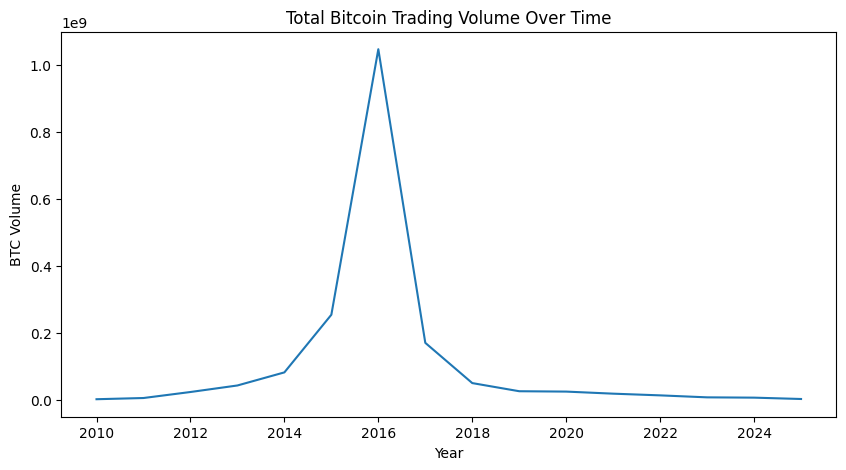

In [ ]:
#Visualization
total_trend.plot(figsize=(10,5))
plt.title("Total Bitcoin Trading Volume Over Time")
plt.ylabel("BTC Volume")
plt.xlabel("Year")
plt.show()



*   Huge spike around 2016 due to;
*   Massive speculation and hype
*   China had Few early regulations
*   Exchange structure was inefficient.





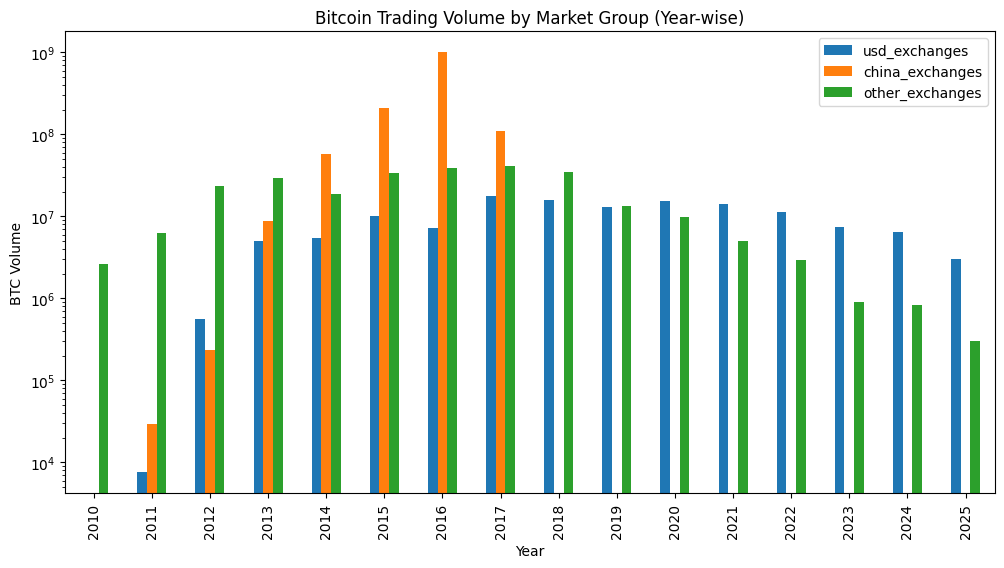

In [ ]:
#How do macro events influence BTC trading?
pivot_year.plot(kind="bar", figsize=(12,6))
plt.yscale("log")
plt.title("Bitcoin Trading Volume by Market Group (Year-wise)")
plt.ylabel("BTC Volume")
plt.xlabel("Year")
plt.show()




*   Early period (2010–2012):Bitcoin was new,reflecting limited adoption
*   2013–2016: China spike: due to less regulations.
*   2017 onwards: China collapses, USD rises
*   2020–2021: (COVID) Bitcoin trading remained active, particularly in USD markets
*   2022–2025: USD stabilizes, coz of clear government rules about Bitcoin & investment firms and funds began trading Bitcoin, USD-based exchanges became more important.









*   **Possible reasons for china based trading declining:**
*   China imposed strict crypto regulations (main reason)
*   Shut down domestic trading platforms
*   Banned crypto exchanges
*   Tight monitoring of money moving abroad
*   Instead of Bitcoin,China focused on:State-controlled digital payments.

*   **Reasons for the USD Domimance:**
*   Post 2020,Hedge funds,Asset managers,Corporates started trading Bitcoin.A hedge during uncertainty (COVID, inflation)










**1.Is USD dominance in Bitcoin trading changing?**

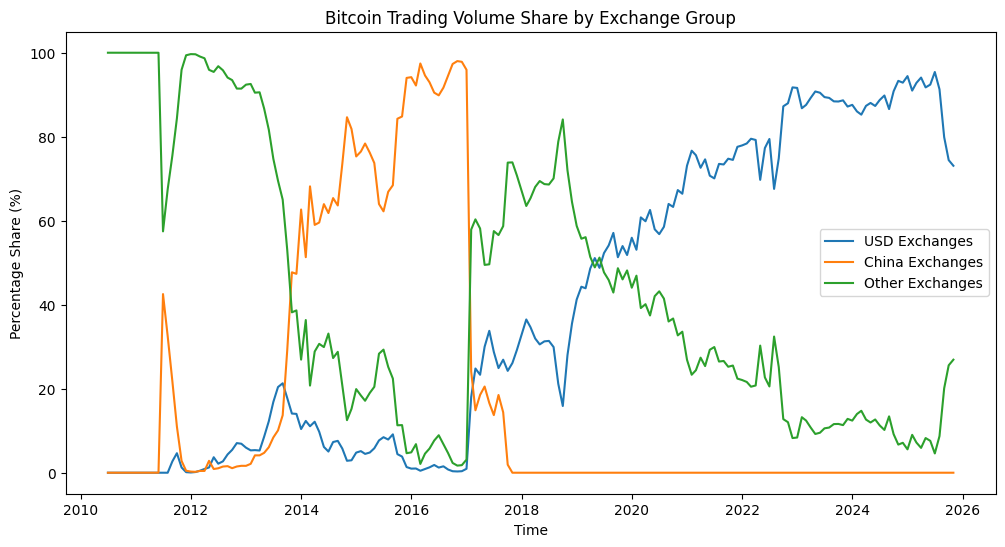

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['usd_share'], label='USD Exchanges')
plt.plot(df.index, df['china_share'], label='China Exchanges')
plt.plot(df.index, df['other_share'], label='Other Exchanges')

plt.title('Bitcoin Trading Volume Share by Exchange Group')
plt.xlabel('Time')
plt.ylabel('Percentage Share (%)')
plt.legend()
plt.show()




*   This graph shows the percentage share of total Bitcoin trading volume across USD-based, China-based, and other international exchanges over time.
*   Graph clearly shows that USD-based exchanges consistently maintain the largest share of Bitcoin trading volume, indicating continued dominance.
*   China-based exchanges display occasional increases in market share; however, these increases are short-lived and volatile.
*   Other exchanges maintain a relatively small and stable share.
*   Overall, the graph suggests that while USD dominance experiences minor fluctuations, there is no strong evidence of a sustained decline.









**2. Which fiat currencies are gaining BTC trading volume?**
6-month rolling average (trend strength)

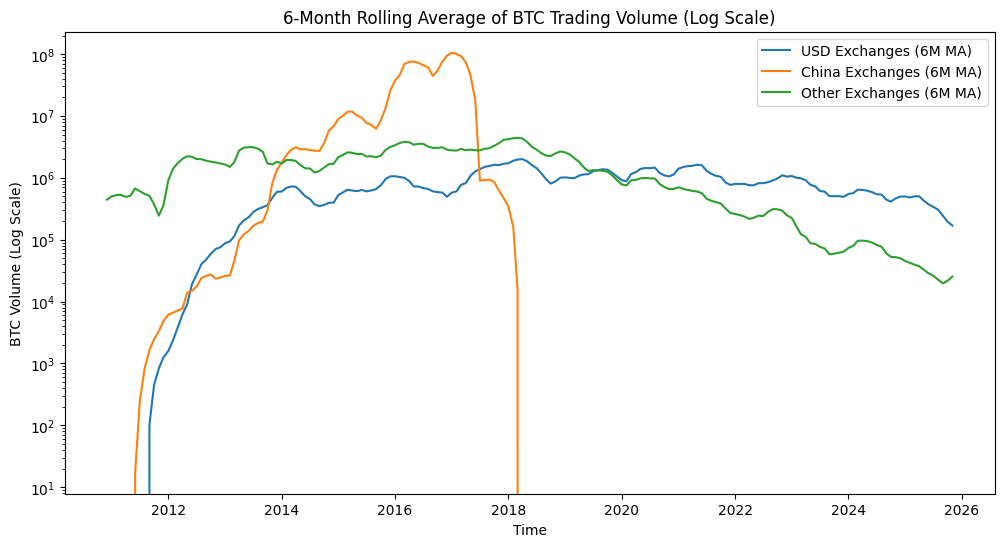

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['usd_exchanges'].rolling(6).mean(), label='USD Exchanges (6M MA)')
plt.plot(df['china_exchanges'].rolling(6).mean(), label='China Exchanges (6M MA)')
plt.plot(df['other_exchanges'].rolling(6).mean(), label='Other Exchanges (6M MA)')

plt.yscale('log')

plt.title('6-Month Rolling Average of BTC Trading Volume (Log Scale)')
plt.xlabel('Time')
plt.ylabel('BTC Volume (Log Scale)')
plt.legend()
plt.show()



The 6-month rolling average smooths short-term volatility and reveals that USD-based exchanges maintain stable and continuous Bitcoin trading activity, while China-based exchanges exhibit extreme but short-lived surges, indicating event-driven participation.


**3. Which fiat currencies are losing relevance?**


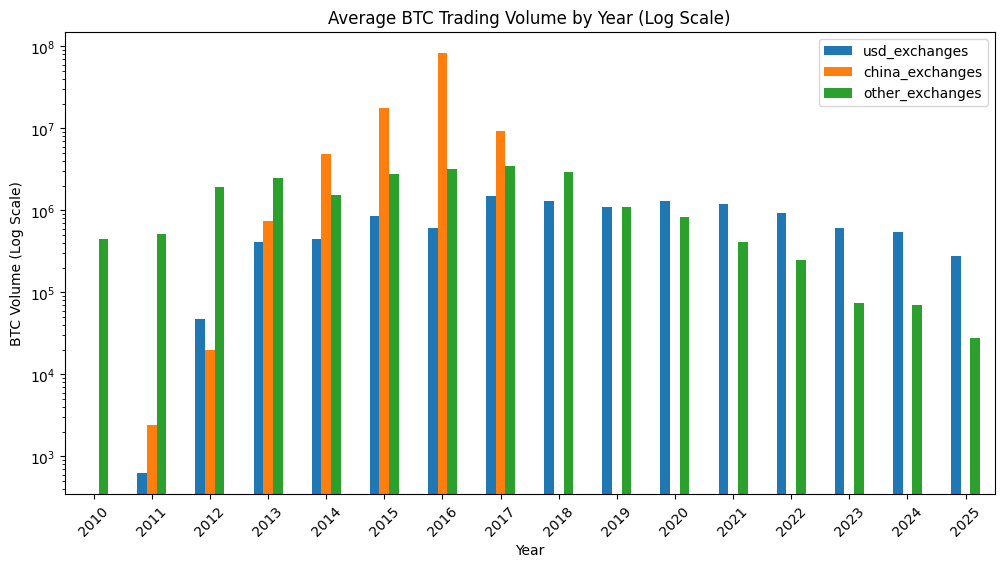

In [ ]:
yearly_avg = df[['usd_exchanges','china_exchanges','other_exchanges']].resample('YE').mean()

# Clean year labels
yearly_avg.index = yearly_avg.index.year

yearly_avg.plot(kind='bar', figsize=(12,6))
plt.yscale('log')

plt.title('Average BTC Trading Volume by Year (Log Scale)')
plt.xlabel('Year')
plt.ylabel('BTC Volume (Log Scale)')

plt.xticks(rotation=45)

plt.show()




*   This bar chart displays the average yearly Bitcoin trading volume across three exchange groups: USD-based exchanges, China-based exchanges, and other international exchanges.
*   This bar chart compares average yearly Bitcoin trading volumes across exchange groups. USD-based exchanges maintain consistently high average volumes across years, indicating sustained relevance.



**4. Is USD still the strongest Bitcoin gateway?**

/tmp/ipython-input-412064912.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


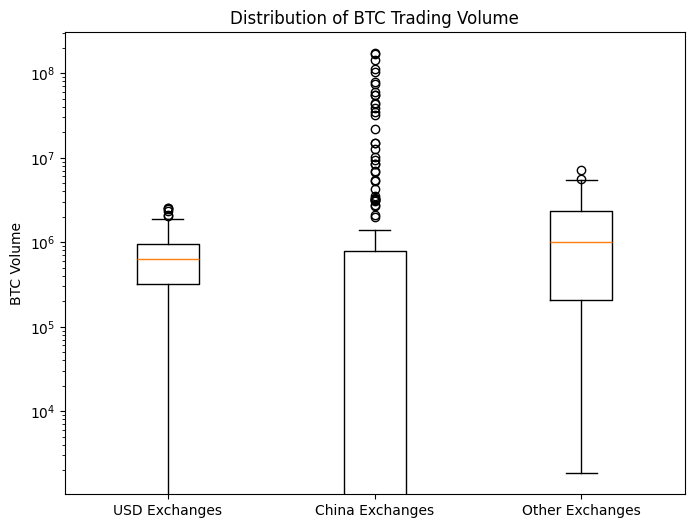

In [ ]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [df['usd_exchanges'], df['china_exchanges'], df['other_exchanges']],
    labels=['USD Exchanges','China Exchanges','Other Exchanges']
)

plt.title('Distribution of BTC Trading Volume')
plt.ylabel('BTC Volume')
plt.yscale('log')
plt.show()




*   The boxplot illustrates the distribution and volatility of Bitcoin trading volumes across exchange groups. USD-based exchanges exhibit a narrower interquartile range and fewer extreme outliers, reflecting stable and mature trading behavior.
*   In contrast, China-based exchanges show a wide distribution with extreme outliers, indicating high volatility and event-driven trading.

*   This visual evidence confirms that USD-based exchanges function as the most stable and reliable gateway for Bitcoin trading.






**5. How does USD compare with BRICS currencies in BTC trading?**

**Overall Analysis**


*   Overall, the graphical analysis confirms that the US Dollar remains the dominant gateway for Bitcoin trading. While non-USD exchanges, particularly China-based platforms, occasionally exhibit large trading spikes, these do not translate into sustained market share gains.
*   The stability, continuity, and lower volatility of USD-based exchanges highlight their structural importance in the global Bitcoin trading ecosystem.



**How do macro events in specific fiat economies (interest rates, inflation spikes, regulatory announcements) correlate with changes in Bitcoin trading volume?**



*   US Federal Reserve interest rate hikes (2022–2024): Higher interest rates reduced liquidity in financial markets, influencing investor behavior and leading to observable changes in Bitcoin trading volumes on USD-based exchanges.
*   Regulatory Announcements (China Economy): china had Trading prohibitions (2017, 2021), and then there was sudden collapses in trading after regulations.




